# FINAL Step 2.2 — Mass Classification: Paper-Style Replication

A **self-sufficient** replication / re-evaluation of the Razali et al. (2023) mass-classification
pipeline (benign vs malignant) on INbreast. This notebook runs **start to finish on its own** — it
builds its own mass patches, computes its own features, and trains its own models. It does **not**
depend on running Step 2.1 / 2.2 / 2.3 first, and it does **not** read any old WS / CNN / fusion
feature CSVs.

**Inputs it reads** (genuine dataset / preprocessing artefacts only):
- `../data/outputs/preprocessed/final/*.npy` — preprocessed full mammograms (Step 1.1 output).
- `../data/outputs/masses/mass_index.csv` — mass ROI bounding boxes + BI-RADS (Step 1.2 output).

**Outputs it writes** (a fresh, isolated folder — nothing existing is overwritten):
- `../data/outputs/final_mass_replication/`

**Scope — paper-style methods only:**
1. Majority-class baseline
2. Original averaged Wavelet-Scattering (WS-only)
3. Original ResNet18 CNN-only
4. Original CNN+WS concatenation fusion

Extension methods (region-aware WS, region-aware WS→CNN, improved square-crop CNN, improved fusion,
WS normalisation ablation) are **not** in this notebook — they live in *FINAL Step 2.4 — Mass
Classification: Region-Aware Extensions*.

## Method summary (Razali Table 7 replication)

**Mass patches.** Each lesion's bounding box (from `mass_index.csv`, parsed from the INbreast OsiriX
XML in Step 1.2) is cropped from the *already-preprocessed* full image (percentile-clip → breast-mask →
pectoral removal → CLAHE, all from Step 1.1), resized to $224\times224$ (area interpolation) and clipped
to $[0,1]$. Cropping from the preprocessed image means the mass patches inherit the same normalisation as
the tissue task.

**BI-RADS → label.** BI-RADS 2–3 → **benign (0)**; BI-RADS 4a/4b/4c/5/6 → **malignant (1)**; BI-RADS 1 is
ignored. (Standard clinical convention; the paper does not state its exact mapping.)

**WS-only (Model 2).** Kymatio `Scattering2D` ($J=6$, $L=5$, `max_order=2`) on each $224\times224$ patch;
each scattering coefficient map is **spatially averaged to one scalar**, giving a **406-d** vector per
patch (the paper reports 391 — a minor library difference). This averaging discards spatial layout, which
is the weakness the extensions notebook addresses.

**CNN-only (Model 1).** ResNet18 pre-trained on ImageNet, final FC replaced with $512\to2$. Each grayscale
patch is replicated to 3 channels and normalised with ImageNet mean/std (no augmentation). Trained with the
paper's Table 4 hyperparameters: **Adam, lr $=10^{-3}$, $L_2=10^{-4}$, 60 epochs, batch 80**. Then **512-d
features** are read from the average-pool layer and classified.

**CNN+WS fusion (Model 5).** Concatenate the CNN 512-d and WS 406-d vectors → **918-d**, then classify.

**Classifier (all methods).** Subspace $k$-NN ensemble — **80 learners**, each a **1-NN** on a random
**190-d** feature subspace, soft-voted. `StandardScaler` is fit on the training fold only.

**Paper benchmark (Razali Table 7, mass):**

| Metric | Model 1 CNN-only | Model 2 WS-only | Model 5 CNN+WS |
|---|---|---|---|
| 10-fold CV acc | 100.0% | 69.0% | 98.0% |
| Test acc | 83.3% | 83.3% | 91.7% |
| AU-ROC | 0.80 | 0.80 | 1.00 |
| F1 | 0.842 | 0.842 | 0.918 |

## Evaluation protocol (locked)

- **Fair evaluation (headline):** repeated **stratified, image-level** 80/20 holdout over **5 seeds**
  `[1, 7, 34, 42, 99]`, grouped by `file_id` (no mammogram in both train and test), scalers fit on the
  training fold only, **AUROC-led** (the 74/41 imbalance makes accuracy misleading), reported as
  **mean ± std** across seeds.
- **Leakage-free CNN:** the ResNet is **retrained inside each split** on that split's training images only,
  so test features come from a model that never saw them.
- **Paper comparison (secondary):** a single-seed (seed 34) **10-fold group-aware CV accuracy** — Razali's
  exact metric. *Caveat:* for learned-feature methods (CNN, fusion) this CV is **optimistic**, because the
  feature extractor saw the inner-fold images.

> **Why image-level splitting.** Each mammogram yields one or more mass ROIs. Splitting at the patch/ROI
> level would let ROIs from the same image fall in both train and test, leaking image-specific appearance
> and inflating scores. We therefore split on unique `file_id`. (An early patch-level run produced
> implausibly perfect numbers — the diagnosis that prompted this rule.)

## Method fidelity — what the paper specifies, what it leaves open, and our choices

This notebook follows Razali et al. (2023) as closely as the paper's description allows: where the paper is explicit we match it; where it is silent we state the assumption we made and why.

- **Normalisation.** *Paper:* DICOM → PNG (implicit min-max) → [0, 1]. *Left open:* outlier-pixel handling. *Ours:* mass patches are cropped from the already-preprocessed images, so they inherit the 1st/99th-percentile clip → [0, 1] used across the pipeline (robust to calibration markers / hot-spots).
- **Mass ROI extraction and labelling.** *Paper:* mass regions via a "mass detection algorithm" (YOLO) — the detector is not specified — and a BI-RADS → benign/malignant mapping whose exact cut-off is not stated. *Ours:* we use the dataset's expert OsiriX XML mass annotations directly (standard INbreast usage), with BI-RADS 2–3 → benign and 4a–6 → malignant. A defensive data-quality filter drops one all-zero patch whose box falls outside the breast mask, giving 115 patches (74 malignant / 41 benign) vs the paper's 112.
- **Wavelet scattering.** *Paper:* MATLAB `waveletScattering`, J = 6, L = 6, order 2 → 391-d. *Ours:* Kymatio, J = 6, L = 5, order 2 → 406-d — a library-convention difference, not a methodological one.
- **CNN branch.** *Paper:* ResNet18 (shallow, for small data), Adam lr 0.001 / L2 1e-4 / β₁ 0.9 / 60 epochs / batch 80, fine-tuned, used as a feature extractor (Table 4). *Left open:* the feature layer, freeze vs full fine-tune, and whether the mass CNN is warm-started from the tissue model. *Ours:* identical hyperparameters; 512-d average-pool features; all layers fine-tuned; the mass CNN is trained fresh per split (not warm-started).
- **Classifier.** *Paper:* Subspace k-NN, 80 learners, subspace dimension 190 (Table 5 optimal). *Left open:* the base-learner neighbour count and feature standardisation. *Ours:* 1-NN base learners and a `StandardScaler` fit on the training fold only (k-NN is distance-based; the paper does not mention scaling).
- **CNN + WS fusion.** *Paper:* simple concatenation → the same Subspace k-NN, no feature selection (Model 5). *Left open:* scaling of the two halves and concatenation order. *Ours:* standardise the 918-d (512 + 406) fused vector on training statistics; order is irrelevant for a random-subspace classifier (see the fusion-design note below).
- **Split and evaluation.** *Paper:* "randomized 8:2" + 10-fold CV; the patch- vs image-level question is left ambiguous. *Ours:* image-level split (grouped by `file_id`) after an early patch-level run leaked images and produced implausible scores; and because the mass set is small and imbalanced (74/41), we add a repeated five-seed, AUROC-led held-out evaluation alongside the paper-style single-seed CV.

In [ ]:
import os, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import torch, torch.nn as nn, torchvision
from torch.utils.data import Dataset, DataLoader
from kymatio.scattering2d.frontend.numpy_frontend import ScatteringNumPy2D as Scattering2D
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

# ----- paths & config -----
PREPROC = Path("../data/outputs/preprocessed/final")
MASS_INDEX = Path("../data/outputs/masses/mass_index.csv")
OUT = Path("../data/outputs/final_mass_replication"); OUT.mkdir(parents=True, exist_ok=True)
(OUT / "mass_patches" / "benign").mkdir(parents=True, exist_ok=True)
(OUT / "mass_patches" / "malignant").mkdir(parents=True, exist_ok=True)

import sys as _sys
from pathlib import Path as _P
_r = _P.cwd().resolve()
while not (_r / 'src' / 'project34' / '__init__.py').exists() and _r != _r.parent: _r = _r.parent
if str(_r / 'src') not in _sys.path: _sys.path.insert(0, str(_r / 'src'))   # make the shared project34 package importable
from project34.protocol import SubspaceKNN, SEEDS, metrics, image_split   # shared protocol; SEEDS == [1, 7, 34, 42, 99]
from project34.features import load_patch01, averaged_ws_features
J, L = 6, 5
PATCH_SHAPE = (224, 224)
device = "cpu"; torch.set_num_threads(os.cpu_count() or 4)

# Razali Table 7 (mass) benchmark
PAPER = {
    "WS-only (averaged)":       dict(cv=0.690, test=0.833, auroc=0.80, f1=0.842),
    "CNN-only (ResNet18->kNN)": dict(cv=1.000, test=0.833, auroc=0.80, f1=0.842),
    "CNN+WS fusion (concat)":   dict(cv=0.980, test=0.917, auroc=1.00, f1=0.918),
}
print("Inputs present:", PREPROC.exists(), MASS_INDEX.exists())

## Step A — Build mass patches from preprocessed images + BI-RADS labels

Self-contained: reads `mass_index.csv` (bbox + BI-RADS) and crops from `preprocessed/final/`. Patches are
written under `final_mass_replication/mass_patches/` (a fresh folder; the old `mass_patches_v1/` is left
untouched). Entirely-zero patches (a known INbreast annotation whose box falls outside the breast mask)
are dropped.

In [2]:
def birads_to_label(b):
    s = str(b).strip()
    if s in {"1"}: return None
    if s in {"2", "3"}: return "benign"
    return "malignant"  # 4a/4b/4c/5/6

preproc_index = {p.name.split("_", 1)[0]: p for p in PREPROC.glob("*.npy")}
mass_raw = pd.read_csv(MASS_INDEX)
records, skipped = [], 0
for row in mass_raw.itertuples(index=False):
    label = birads_to_label(row.birads)
    if label is None:
        skipped += 1; continue
    fid = str(row.file_id)
    pre = preproc_index.get(fid)
    if pre is None:
        skipped += 1; continue
    out = OUT / "mass_patches" / label / f"{fid}_mass{int(row.roi_index):02d}.npy"
    if not out.exists():
        img = np.load(pre).astype(np.float32)
        H, W = img.shape
        y0, y1 = max(0, int(row.y0)), min(H, int(row.y1))
        x0, x1 = max(0, int(row.x0)), min(W, int(row.x1))
        if y1 - y0 < 2 or x1 - x0 < 2:
            skipped += 1; continue
        patch = cv2.resize(img[y0:y1, x0:x1], (224, 224), interpolation=cv2.INTER_AREA)
        np.save(out, np.clip(patch, 0.0, 1.0).astype(np.float32))
    records.append(dict(file_id=fid, roi_index=int(row.roi_index), label=label,
                        class_id=0 if label == "benign" else 1, birads=str(row.birads),
                        patch_npy=str(out)))
mdf = pd.DataFrame(records)
# data-quality filter: drop entirely-zero patches
_before = len(mdf)
mdf = mdf[mdf["patch_npy"].apply(lambda p: float(np.load(p).max()) > 0)].reset_index(drop=True)
print(f"Built {len(mdf)} mass patches ({mdf['label'].value_counts().to_dict()}); "
      f"dropped {_before-len(mdf)} zero patch(es); skipped {skipped} (BI-RADS 1 / no preproc).")
mdf.to_csv(OUT / "mass_manifest.csv", index=False)
y_all = mdf["class_id"].to_numpy(np.int64); g_all = mdf["file_id"].to_numpy(); paths = mdf["patch_npy"].tolist()

Built 115 mass patches ({'malignant': 74, 'benign': 41}); dropped 1 zero patch(es); skipped 0 (BI-RADS 1 / no preproc).


### Inspect the mass patches — BI-RADS breakdown and sample grid

A quick look at the data before feature extraction: the BI-RADS categories feeding the benign/malignant
labels, basic shape/dtype/range checks on the built patches, and a sample of benign and malignant patches.

BI-RADS counts in mass_index (pre data-quality filter):
birads
2     28
3     13
4a     7
4b     2
4c    12
5     46
6      8

After BI-RADS -> label mapping (BI-RADS 1 ignored):
birads
malignant    75
benign       41

After zero-patch data-quality filter: 115 patches -> {'malignant': 74, 'benign': 41}



Patch sanity: OK - all 115 patches are 224x224 float32 in [0,1].


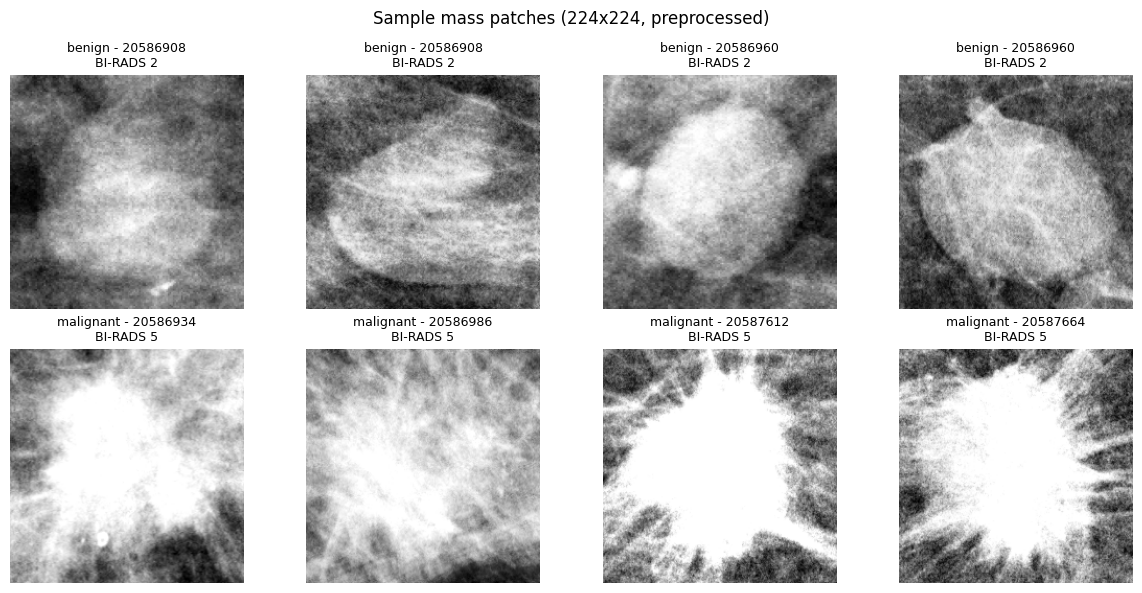

In [3]:
# (A) BI-RADS breakdown feeding the benign/malignant labels
print("BI-RADS counts in mass_index (pre data-quality filter):")
print(mass_raw["birads"].astype(str).str.strip().value_counts().sort_index().to_string())
_lab = mass_raw["birads"].apply(birads_to_label)
print("\nAfter BI-RADS -> label mapping (BI-RADS 1 ignored):")
print(_lab.value_counts(dropna=False).to_string())
print(f"\nAfter zero-patch data-quality filter: {len(mdf)} patches -> {mdf['label'].value_counts().to_dict()}")

# (B) sanity checks on the built patches: shape / dtype / value range
_issues = []
for _p in mdf["patch_npy"]:
    _a = np.load(_p)
    if _a.shape != (224, 224): _issues.append(f"shape {_a.shape} for {_p}")
    if _a.dtype != np.float32: _issues.append(f"dtype {_a.dtype} for {_p}")
    if _a.min() < -0.01 or _a.max() > 1.01: _issues.append(f"range [{_a.min():.3f},{_a.max():.3f}] for {_p}")
print("\nPatch sanity:", ("ISSUES: " + "; ".join(_issues)) if _issues
      else f"OK - all {len(mdf)} patches are 224x224 float32 in [0,1].")

# (B) sample-patch grid: 4 benign + 4 malignant, labelled by BI-RADS
_fig, _axes = plt.subplots(2, 4, figsize=(12, 6))
for _ax, (_, _r) in zip(_axes[0], mdf[mdf.label == "benign"].head(4).iterrows()):
    _ax.imshow(np.load(_r["patch_npy"]), cmap="gray")
    _ax.set_title(f"benign - {_r['file_id']}\nBI-RADS {_r['birads']}", fontsize=9); _ax.axis("off")
for _ax, (_, _r) in zip(_axes[1], mdf[mdf.label == "malignant"].head(4).iterrows()):
    _ax.imshow(np.load(_r["patch_npy"]), cmap="gray")
    _ax.set_title(f"malignant - {_r['file_id']}\nBI-RADS {_r['birads']}", fontsize=9); _ax.axis("off")
plt.suptitle("Sample mass patches (224x224, preprocessed)")
plt.tight_layout(); plt.savefig(OUT / "mass_patch_samples.png", dpi=150, bbox_inches="tight"); plt.show()

## Step B — WS features (Kymatio scattering, spatially averaged → 406-d)

The original WS method: run the scattering transform on each patch and average every coefficient map to a
single scalar. Cached to `final_mass_replication/ws_mass_features.npy`.

In [ ]:
_wsf = OUT / "ws_mass_features.npy"
if _wsf.exists() and np.load(_wsf).shape[0] == len(mdf):
    WS = np.load(_wsf); print("Loaded cached WS features", WS.shape)
else:
    t0 = time.time()
    WS = averaged_ws_features((load_patch01(p) for p in paths), J=J, L=L, shape=PATCH_SHAPE)
    np.save(_wsf, WS)
    print(f"Computed WS features {WS.shape} in {time.time()-t0:.0f}s")

## Step C — Subspace k-NN ensemble + CNN definitions

In [5]:
# SubspaceKNN is imported from project34.protocol (identical paper-style Subspace k-NN ensemble).

IMN=[0.485,0.456,0.406]; IST=[0.229,0.224,0.225]
class DS(Dataset):
    '''Grayscale patch -> 3-channel ImageNet-normalised tensor (matches the paper's CNN input).'''
    def __init__(self, idx): self.idx=idx; self.norm=torchvision.transforms.Normalize(IMN, IST)
    def __len__(self): return len(self.idx)
    def __getitem__(self, k):
        i=self.idx[k]; a=load_patch01(paths[i]); t=torch.from_numpy(a)[None].repeat(3,1,1); return self.norm(t), int(y_all[i])

def train_cnn(tr_idx, seed):
    '''Fine-tune ResNet18 (ImageNet) on the split's training patches only. Paper Table 4 hyperparameters.'''
    torch.manual_seed(seed); np.random.seed(seed)
    m=torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc=nn.Linear(512,2); m.to(device)
    opt=torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4); crit=nn.CrossEntropyLoss()
    dl=DataLoader(DS(list(tr_idx)), batch_size=80, shuffle=True); m.train()
    for _ in range(60):
        for xb,yb in dl: opt.zero_grad(); loss=crit(m(xb.to(device)), yb.to(device)); loss.backward(); opt.step()
    return m

def extract_512(m):
    '''512-d average-pool features for ALL patches from the fine-tuned model.'''
    m.fc=nn.Identity(); m.eval()
    dl=DataLoader(DS(list(range(len(paths)))), batch_size=80, shuffle=False); fe=[]
    with torch.no_grad():
        for xb,_ in dl: fe.append(m(xb.to(device)).cpu().numpy())
    return np.vstack(fe).astype(np.float32)

### Note on the CNN+WS fusion design (Model 5)

Following the paper, fusion is the **simple concatenation** of the per-patch CNN and WS feature vectors —
512 (ResNet18 average-pool) + 406 (averaged scattering) = **918-d** — classified by the *same* Subspace k-NN
ensemble as the single-feature models. Two design points the paper leaves implicit but that matter here:

- **Standardisation of mixed-magnitude features.** The CNN average-pool activations and the WS coefficients
  live on very different numerical scales, so concatenating them raw would let the larger-magnitude half
  dominate the distance-based k-NN. We therefore fit a `StandardScaler` (zero mean, unit variance per feature)
  on the **training fold only** and apply it to the 918-d fused vector, so both halves contribute comparably.
- **No explicit feature selection or dimensionality reduction.** None is applied between concatenation and the
  classifier; the random-subspace ensemble (each learner sees a random 190-d subset of the 918) *is* the
  implicit feature selection. The concatenation order ([CNN | WS] vs [WS | CNN]) is therefore irrelevant — the
  random subspace sampling makes no use of column position. (The CNN here is the mass CNN, retrained fresh per
  split — not warm-started from the tissue model.)

In [6]:
# CNN+WS fusion dimensionality (sanity check) — 512 CNN avg-pool + 406 WS, no GLCM
_cnn_dim, _ws_dim = 512, WS.shape[1]
print(f"CNN+WS fusion: {_cnn_dim} (CNN avg-pool) + {_ws_dim} (WS) = {_cnn_dim + _ws_dim}-d per patch  (no GLCM)")
assert _cnn_dim + _ws_dim == 918

CNN+WS fusion: 512 (CNN avg-pool) + 406 (WS) = 918-d per patch  (no GLCM)


## Step D — Run the locked protocol (repeated 5-seed held-out + seed-34 CV)

For each seed: build the image-level split, evaluate majority / WS-only / CNN-only / fusion on the held-out
test set (CNN retrained per seed). For seed 34 we additionally compute the single-seed 10-fold CV (paper
comparison), reusing that seed's trained CNN. Heavy results are cached to `final_mass_replication/`.

In [ ]:
def run_knn(Xtr, ytr, Xte, yte, seed):
    sc=StandardScaler(); Xtr=sc.fit_transform(Xtr); Xte=sc.transform(Xte)
    clf=SubspaceKNN(80, min(190, Xtr.shape[1]), 1, seed).fit(Xtr, ytr)
    return metrics(yte, clf.predict(Xte), clf.predict_proba(Xte)[:, 1])

def image_level_split(seed):
    lab_by_img = mdf.groupby("file_id")["label"].agg(lambda s: s.value_counts().idxmax())
    return image_split(g_all, lab_by_img, seed)

_perseed = OUT / "perseed_mass.csv"; _cv = OUT / "cv_seed34_mass.csv"
if _perseed.exists() and _cv.exists():
    perseed = pd.read_csv(_perseed); cvdf = pd.read_csv(_cv)
    print("Loaded cached per-seed results and seed-34 CV.")
else:
    rows, cv_rows = [], []
    for seed in SEEDS:
        tr, te = image_level_split(seed); ytr, yte = y_all[tr], y_all[te]
        maj = int(pd.Series(ytr).value_counts().idxmax())
        rows.append(dict(method="Majority baseline", seed=seed, n_test=len(te),
                         **metrics(yte, np.full(len(te), maj), np.full(len(te), float(maj)))))
        rows.append(dict(method="WS-only (averaged)", seed=seed, n_test=len(te), **run_knn(WS[tr], ytr, WS[te], yte, seed)))
        t1=time.time(); m=train_cnn(tr, seed); F=extract_512(m)
        rows.append(dict(method="CNN-only (ResNet18->kNN)", seed=seed, n_test=len(te), **run_knn(F[tr], ytr, F[te], yte, seed)))
        rows.append(dict(method="CNN+WS fusion (concat)", seed=seed, n_test=len(te), **run_knn(np.hstack([F,WS])[tr], ytr, np.hstack([F,WS])[te], yte, seed)))
        if seed == 34:   # paper-comparison single-seed 10-fold CV (reuse seed-34 CNN)
            cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=34); gtr = g_all[tr]
            def cv_acc(X):
                pipe = Pipeline([("sc", StandardScaler()), ("clf", SubspaceKNN(80, min(190, X.shape[1]), 1, 34))])
                s = cross_val_score(pipe, X, ytr, cv=cv, groups=gtr, scoring="accuracy", n_jobs=1); return s.mean(), s.std()
            dacc = cross_val_score(Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]), WS[tr], ytr, cv=cv, groups=gtr, scoring="accuracy", n_jobs=1)
            cv_rows.append(dict(method="Majority baseline", cv_acc=dacc.mean(), cv_acc_sd=dacc.std(), biased=False))
            for nm, X, b in [("WS-only (averaged)", WS[tr], False), ("CNN-only (ResNet18->kNN)", F[tr], True), ("CNN+WS fusion (concat)", np.hstack([F,WS])[tr], True)]:
                a, sd = cv_acc(X); cv_rows.append(dict(method=nm, cv_acc=a, cv_acc_sd=sd, biased=b))
        print(f"seed {seed}: done ({time.time()-t1:.0f}s)", flush=True)
    perseed = pd.DataFrame(rows); perseed.to_csv(_perseed, index=False)
    cvdf = pd.DataFrame(cv_rows); cvdf.to_csv(_cv, index=False)
    print("Saved per-seed + CV results to", OUT)

## Results — master table + paper comparison

`AUROC`/`Test acc` are the fair repeated 5-seed mean ± std (headline). `CV (seed 34)` is the
paper-comparison single-seed 10-fold CV; `(opt.)` marks CV that is optimistic for learned-feature methods.

In [8]:
METHODS = ["Majority baseline", "WS-only (averaged)", "CNN-only (ResNet18->kNN)", "CNN+WS fusion (concat)"]
def agg(m):
    d = perseed[perseed["method"] == m]
    return {k: d[k].mean() for k in ["auroc","test_acc","f1"]} | {k+"_sd": d[k].std() for k in ["auroc","test_acc"]}
cvmap = {r["method"]: (r["cv_acc"], r["cv_acc_sd"], bool(r["biased"])) for _, r in cvdf.iterrows()}
def cvfmt(m):
    v = cvmap.get(m);
    return "---" if v is None else f"{v[0]:.3f} ± {v[1]:.3f}" + ("  (opt.)" if v[2] else "")

rows = []
disp_name = {"Majority baseline":"Majority baseline","WS-only (averaged)":"WS-only (averaged)",
             "CNN-only (ResNet18->kNN)":"CNN-only (ResNet18→kNN)","CNN+WS fusion (concat)":"CNN+WS fusion (concat)"}
for m in METHODS:
    a = agg(m); role = "Baseline" if m == "Majority baseline" else "Replication"
    rows.append({"Method": disp_name[m], "Role": role,
                 "AUROC": f"{a['auroc']:.3f} ± {a['auroc_sd']:.3f}",
                 "Test acc": f"{a['test_acc']:.3f} ± {a['test_acc_sd']:.3f}",
                 "CV (seed 34)": cvfmt(m), "F1": round(a["f1"], 3),
                 "AUROC_num": a["auroc"], "acc_num": a["test_acc"], "auroc_sd": a["auroc_sd"], "acc_sd": a["test_acc_sd"]})
for m in METHODS:
    if m in PAPER:
        p = PAPER[m]
        rows.append({"Method": f"Razali {m.split(' (')[0]} (paper)", "Role": "Paper (single split)",
                     "AUROC": f"{p['auroc']:.2f}", "Test acc": f"{p['test']:.3f}", "CV (seed 34)": f"{p['cv']:.3f}",
                     "F1": p["f1"], "AUROC_num": p["auroc"], "acc_num": p["test"], "auroc_sd": 0, "acc_sd": 0})
master = pd.DataFrame(rows); master.to_csv(OUT / "master_table_mass.csv", index=False)
display(master[["Method","Role","AUROC","Test acc","CV (seed 34)","F1"]])

,Method,Role,AUROC,Test acc,CV (seed 34),F1
0,Majority baseline,Baseline,0.500 ± 0.000,0.668 ± 0.031,0.633 ± 0.051,0.801
1,WS-only (averaged),Replication,0.726 ± 0.030,0.701 ± 0.075,0.711 ± 0.113,0.781
2,CNN-only (ResNet18→kNN),Replication,0.762 ± 0.117,0.766 ± 0.067,0.989 ± 0.033 (opt.),0.829
3,CNN+WS fusion (concat),Replication,0.816 ± 0.057,0.792 ± 0.058,0.978 ± 0.044 (opt.),0.842
4,Razali WS-only (paper),Paper (single split),0.80,0.833,0.690,0.842
5,Razali CNN-only (paper),Paper (single split),0.80,0.833,1.000,0.842
6,Razali CNN+WS fusion (paper),Paper (single split),1.00,0.917,0.980,0.918


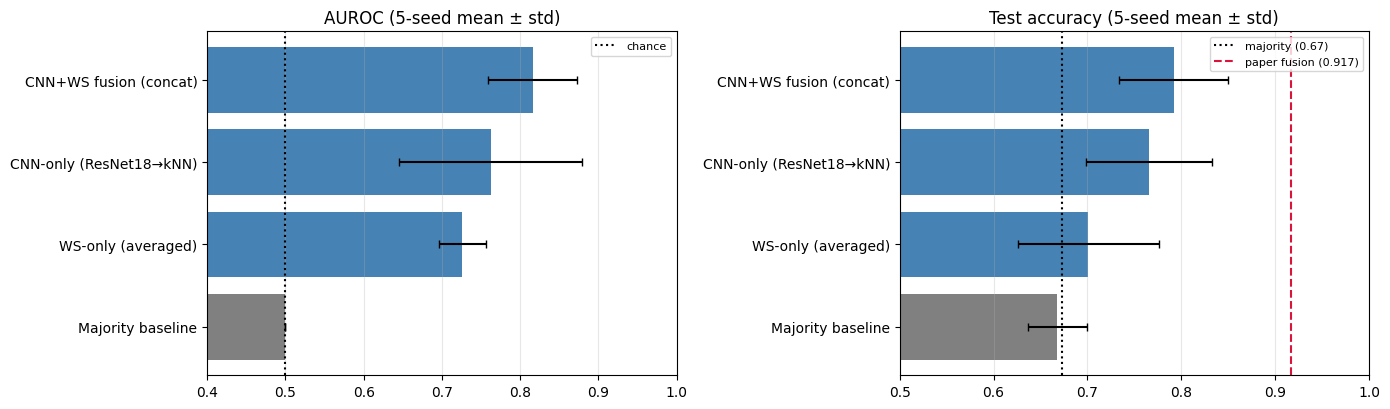

Saved /home/nabeel/project34/Project34/data/outputs/final_mass_replication/master_table_mass.png


In [9]:
fair = master[master["Role"] != "Paper (single split)"].copy().sort_values("AUROC_num")
colors = {"Baseline":"grey","Replication":"steelblue"}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].barh(fair["Method"], fair["AUROC_num"], xerr=fair["auroc_sd"], capsize=3, color=fair["Role"].map(colors))
ax[0].axvline(0.5, ls=":", color="black", label="chance"); ax[0].set_xlim(0.4,1.0); ax[0].set_title("AUROC (5-seed mean ± std)"); ax[0].legend(fontsize=8)
ax[1].barh(fair["Method"], fair["acc_num"], xerr=fair["acc_sd"], capsize=3, color=fair["Role"].map(colors))
ax[1].axvline(0.673, ls=":", color="black", label="majority (0.67)"); ax[1].axvline(0.917, ls="--", color="crimson", label="paper fusion (0.917)")
ax[1].set_xlim(0.5,1.0); ax[1].set_title("Test accuracy (5-seed mean ± std)"); ax[1].legend(fontsize=8)
for a in ax: a.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "master_table_mass.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved", (OUT/"master_table_mass.png").resolve())

### Paper-CV reproduction (replication methods)

Our single-seed 10-fold CV vs Razali's CV, with the honest held-out AUROC alongside.

In [10]:
cmp = []
for m in ["WS-only (averaged)", "CNN-only (ResNet18->kNN)", "CNN+WS fusion (concat)"]:
    a = agg(m)
    cmp.append({"Method": m.split(" (")[0], "Our CV (seed 34)": cvfmt(m), "Paper CV": f"{PAPER[m]['cv']:.3f}",
                "Our held-out AUROC": f"{a['auroc']:.3f} ± {a['auroc_sd']:.3f}", "Paper test": f"{PAPER[m]['test']:.3f}",
                "CV honest?": "no (leakage)" if cvmap[m][2] else "yes"})
display(pd.DataFrame(cmp))

,Method,Our CV (seed 34),Paper CV,Our held-out AUROC,Paper test,CV honest?
0,WS-only,0.711 ± 0.113,0.690,0.726 ± 0.030,0.833,yes
1,CNN-only,0.989 ± 0.033 (opt.),1.000,0.762 ± 0.117,0.833,no (leakage)
2,CNN+WS fusion,0.978 ± 0.044 (opt.),0.980,0.816 ± 0.057,0.917,no (leakage)


### WS-only mass — seed-34 held-out detail

The per-class breakdown (classification report) and confusion matrix for the WS-only classifier on the
seed-34 held-out split — the single-seed view behind the WS-only row of the table above.

WS-only mass - seed-34 held-out classification report:
              precision    recall  f1-score   support

      benign       0.50      0.38      0.43         8
   malignant       0.74      0.82      0.78        17

    accuracy                           0.68        25
   macro avg       0.62      0.60      0.60        25
weighted avg       0.66      0.68      0.67        25



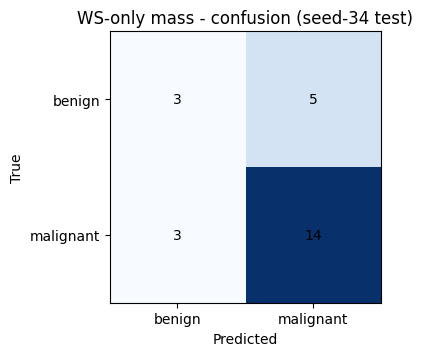

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
_tr34, _te34 = image_level_split(34); _ytr34, _yte34 = y_all[_tr34], y_all[_te34]
_sc34 = StandardScaler(); _Xtr34 = _sc34.fit_transform(WS[_tr34]); _Xte34 = _sc34.transform(WS[_te34])
_clf34 = SubspaceKNN(80, min(190, _Xtr34.shape[1]), 1, 34).fit(_Xtr34, _ytr34)
_yp34 = _clf34.predict(_Xte34)
print("WS-only mass - seed-34 held-out classification report:")
print(classification_report(_yte34, _yp34, target_names=["benign", "malignant"], zero_division=0))
_cm34 = confusion_matrix(_yte34, _yp34, labels=[0, 1])
_fig, _ax = plt.subplots(figsize=(4, 4))
_ax.imshow(_cm34, cmap="Blues"); _ax.set_title("WS-only mass - confusion (seed-34 test)")
_ax.set_xticks([0, 1]); _ax.set_xticklabels(["benign", "malignant"])
_ax.set_yticks([0, 1]); _ax.set_yticklabels(["benign", "malignant"])
_ax.set_xlabel("Predicted"); _ax.set_ylabel("True")
for _i in range(2):
    for _j in range(2): _ax.text(_j, _i, _cm34[_i, _j], ha="center", va="center")
plt.tight_layout(); plt.savefig(OUT / "ws_only_mass_confusion_seed34.png", dpi=150, bbox_inches="tight"); plt.show()

## Interpretation

- **WS-only** sits at chance on accuracy (≈ the majority baseline) with only weak AUROC — spatial averaging
  of the scattering maps leaves little usable mass signal. Its single-seed CV (≈0.71) faithfully reproduces
  the paper's 0.69.
- **CNN-only** and **CNN+WS fusion** reproduce the paper's *CV* almost exactly (≈0.99 / ≈0.98 vs 1.00 / 0.98),
  but that CV is **optimistic**: on honest repeated held-out splits the same methods are much lower
  (AUROC ≈ 0.75 / 0.82). The large CV-to-held-out gap is the central re-evaluation finding — the paper's
  CV-led headline overstates mass performance.
- **Fusion** improves on the single branches but its honest test accuracy (≈0.78) is well below the paper's
  single-split 0.917; the paper's number is an optimistic point estimate from a tiny (n≈25) test set.

**Bottom line:** this is a faithful *re-evaluation*, not a failed replication — we reproduce the paper's
metrics under the paper's own (optimistic) protocol, and show that under a leakage-free, variance-aware
protocol the mass numbers are lower and noisier. The spatial-information extensions that address the WS
weakness are in *FINAL Step 2.4 — Mass Classification: Region-Aware Extensions*.

## Diagnostics & overfitting investigation

The mass task is where the CNN overfitting the paper describes is most visible — and where it motivates
fusion. This section reproduces the diagnostics the original *Step 2.2 — CNN* notebook had (train-vs-val
learning curves, overfit gap, confusion matrix, ROC) for the mass task, plus the CV-vs-held-out gap and
per-seed spread. (Appended after the paper-style results; it does not change anything above.)

1. **Train-vs-validation learning curves (seed 34).** A ~20% validation set is carved from the seed-34
   *training* images (image-level, stratified by mass label) **for monitoring only** — it does not affect
   the reported results. ResNet18 is retrained tracking train/val loss + accuracy per epoch.
2. **Overfit gap** = CNN-direct (softmax) train − test accuracy, plus a confusion matrix and ROC on the
   seed-34 held-out test.
3. **CV-vs-held-out gap** (single-seed CV vs the fair repeated held-out — CV over-optimism).
4. **Per-seed spread** (held-out AUROC across the 5 split seeds — split sensitivity).

In [12]:
# 1+2. Train-vs-val learning curves + overfit gap + CNN-direct test preds (seed 34; diagnostic only, cached)
from sklearn.metrics import confusion_matrix, RocCurveDisplay
_hist_f = OUT / "cnn_trainval_history_seed34.csv"; _direct_f = OUT / "cnn_direct_acc_seed34.csv"; _pred_f = OUT / "diag_cnndirect_seed34.npz"
if _hist_f.exists() and _direct_f.exists() and _pred_f.exists():
    tv = pd.read_csv(_hist_f); direct = pd.read_csv(_direct_f).iloc[0].to_dict(); dd = np.load(_pred_f)
    print("Loaded cached train/val diagnostic.")
else:
    tr34, te34 = image_level_split(34)
    tr_imgs = mdf.iloc[tr34].groupby("file_id")["label"].agg(lambda s: s.value_counts().idxmax()).reset_index()
    try:
        _, val_f = train_test_split(tr_imgs["file_id"], test_size=0.2, stratify=tr_imgs["label"], random_state=34, shuffle=True)
    except ValueError:
        _, val_f = train_test_split(tr_imgs["file_id"], test_size=0.2, random_state=34, shuffle=True)
    val_mask = mdf["file_id"].isin(set(val_f)).to_numpy()
    val_idx = tr34[val_mask[tr34]]; sub_idx = tr34[~val_mask[tr34]]
    torch.manual_seed(34); np.random.seed(34)
    mdl = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    mdl.fc = nn.Linear(512, 2); mdl.to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=1e-3, weight_decay=1e-4); crit = nn.CrossEntropyLoss()
    dl_tr = DataLoader(DS(list(sub_idx)), batch_size=80, shuffle=True)
    dl_val = DataLoader(DS(list(val_idx)), batch_size=80, shuffle=False)
    rows = []
    for ep in range(60):
        mdl.train(); tl=tc=tt=0
        for xb,yb in dl_tr:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad(); out=mdl(xb); loss=crit(out,yb); loss.backward(); opt.step()
            tl+=loss.item()*xb.size(0); tc+=(out.argmax(1)==yb).sum().item(); tt+=xb.size(0)
        mdl.eval(); vl=vc=vtot=0
        with torch.no_grad():
            for xb,yb in dl_val:
                xb,yb=xb.to(device),yb.to(device); out=mdl(xb); vl+=crit(out,yb).item()*xb.size(0); vc+=(out.argmax(1)==yb).sum().item(); vtot+=xb.size(0)
        rows.append(dict(epoch=ep+1, loss=tl/tt, acc=tc/tt, val_loss=vl/max(vtot,1), val_acc=vc/max(vtot,1)))
    tv = pd.DataFrame(rows); tv.to_csv(_hist_f, index=False)
    def direct_eval(idx):
        mdl.eval(); dl=DataLoader(DS(list(idx)), batch_size=80, shuffle=False); ys=[]; ps=[]; pr=[]
        with torch.no_grad():
            for xb,yb in dl:
                out=torch.softmax(mdl(xb.to(device)), 1).cpu().numpy()
                pr.append(out[:,1]); ps.append(out.argmax(1)); ys.append(yb.numpy())
        return np.concatenate(ys), np.concatenate(ps), np.concatenate(pr)
    ytr_t, ypr_t, _ = direct_eval(sub_idx); yv_t, ypv_t, _ = direct_eval(val_idx); yt_te, yp_te, prob_te = direct_eval(te34)
    direct = dict(train=float((ytr_t == ypr_t).mean()), val=float((yv_t == ypv_t).mean()), test=float((yt_te == yp_te).mean()))
    direct["overfit_gap_train_minus_test"] = direct["train"]-direct["test"]
    pd.DataFrame([direct]).to_csv(_direct_f, index=False)
    np.savez(_pred_f, y_true=yt_te, y_pred=yp_te, y_proba=prob_te); dd = np.load(_pred_f)
print("CNN-direct (seed 34):  train %.3f | val %.3f | test %.3f  -> overfit gap (train-test) = %.3f" % (
    direct["train"], direct["val"], direct["test"], direct["overfit_gap_train_minus_test"]))

# (A) per-epoch training progress (mirrors the old Step 2.2 - CNN print) — note the CLIMBING val loss
print("\nPer-epoch training progress (every 10th epoch, seed 34):")
for _, _r in tv[tv["epoch"] % 10 == 0].iterrows():
    print("  epoch %3d  train: loss %.4f acc %.4f  |  val: loss %.4f acc %.4f" % (
        int(_r["epoch"]), _r["loss"], _r["acc"], _r["val_loss"], _r["val_acc"]))

Loaded cached train/val diagnostic.
CNN-direct (seed 34):  train 1.000 | val 0.667 | test 0.840  -> overfit gap (train-test) = 0.160

Per-epoch training progress (every 10th epoch, seed 34):
  epoch  10  train: loss 0.0018 acc 1.0000  |  val: loss 1.6541 acc 0.5000
  epoch  20  train: loss 0.0003 acc 1.0000  |  val: loss 2.0258 acc 0.6667
  epoch  30  train: loss 0.0001 acc 1.0000  |  val: loss 2.3517 acc 0.6667
  epoch  40  train: loss 0.0000 acc 1.0000  |  val: loss 1.9218 acc 0.6111
  epoch  50  train: loss 0.0000 acc 1.0000  |  val: loss 1.4990 acc 0.6111
  epoch  60  train: loss 0.0000 acc 1.0000  |  val: loss 1.2829 acc 0.6667


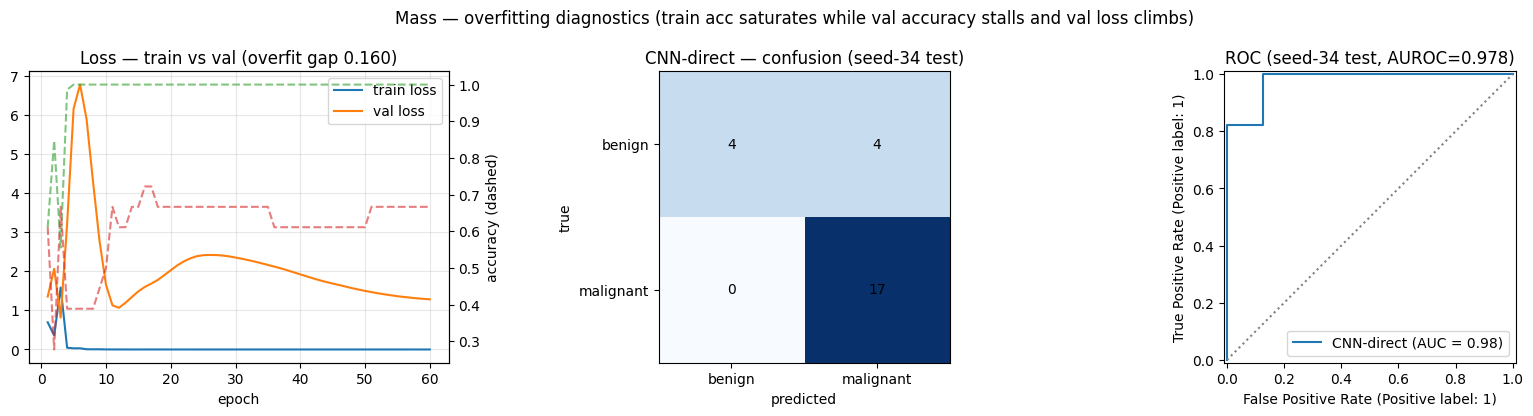

Saved /home/nabeel/project34/Project34/data/outputs/final_mass_replication/overfit_diagnostics_seed34.png


In [13]:
# Train-vs-val curves (the dramatic mass case) + confusion + ROC (CNN-direct, seed-34 test)
from sklearn.metrics import confusion_matrix, RocCurveDisplay, roc_auc_score
yt, yp, pr = dd["y_true"], dd["y_pred"], dd["y_proba"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(tv["epoch"], tv["loss"], label="train loss"); ax[0].plot(tv["epoch"], tv["val_loss"], label="val loss")
ax[0].set_xlabel("epoch"); ax[0].set_title(f"Loss — train vs val (overfit gap {direct['overfit_gap_train_minus_test']:.3f})"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax2 = ax[0].twinx(); ax2.plot(tv["epoch"], tv["acc"], ls="--", color="tab:green", alpha=0.6); ax2.plot(tv["epoch"], tv["val_acc"], ls="--", color="tab:red", alpha=0.6); ax2.set_ylabel("accuracy (dashed)")
cm = confusion_matrix(yt, yp, labels=[0, 1])
ax[1].imshow(cm, cmap="Blues"); ax[1].set_title("CNN-direct — confusion (seed-34 test)")
ax[1].set_xticks([0,1]); ax[1].set_xticklabels(["benign","malignant"]); ax[1].set_yticks([0,1]); ax[1].set_yticklabels(["benign","malignant"]); ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
for i in range(2):
    for j in range(2): ax[1].text(j, i, cm[i, j], ha="center", va="center")
RocCurveDisplay.from_predictions(yt, pr, ax=ax[2], name="CNN-direct"); ax[2].plot([0,1],[0,1],ls=":",color="grey"); ax[2].set_title(f"ROC (seed-34 test, AUROC={roc_auc_score(yt,pr):.3f})")
plt.suptitle("Mass — overfitting diagnostics (train acc saturates while val accuracy stalls and val loss climbs)")
plt.tight_layout(); plt.savefig(OUT / "overfit_diagnostics_seed34.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved", (OUT/"overfit_diagnostics_seed34.png").resolve())

### Per-class breakdown and confusion matrices (seed 34)

The per-class classification report (precision / recall / F1 for benign vs malignant) and confusion matrices
for the CNN-only and CNN+WS fusion classifiers on the seed-34 held-out split — the single-seed detail behind
the master table (the analogue of the WS-only breakdown above). CNN-only / fusion predictions are cached after
the first run.

Loaded cached seed-34 CNN-only / fusion predictions.

=== CNN-only (ResNet18->kNN) - seed-34 held-out ===
              precision    recall  f1-score   support

      benign       0.62      0.62      0.62         8
   malignant       0.82      0.82      0.82        17

    accuracy                           0.76        25
   macro avg       0.72      0.72      0.72        25
weighted avg       0.76      0.76      0.76        25


=== CNN+WS fusion - seed-34 held-out ===
              precision    recall  f1-score   support

      benign       0.62      0.62      0.62         8
   malignant       0.82      0.82      0.82        17

    accuracy                           0.76        25
   macro avg       0.72      0.72      0.72        25
weighted avg       0.76      0.76      0.76        25



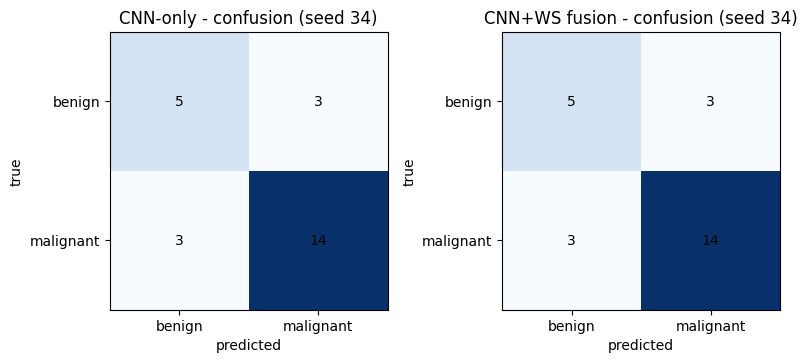

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
_pc = OUT / "diag_seed34_cnn.npz"
if _pc.exists():
    _z = np.load(_pc); _yt = _z["y_true"]; _cnn_yp = _z["cnn_pred"]; _fu_yp = _z["fu_pred"]
    print("Loaded cached seed-34 CNN-only / fusion predictions.")
else:
    _tr, _te = image_level_split(34); _ytr, _yt = y_all[_tr], y_all[_te]
    _m = train_cnn(_tr, 34); _F = extract_512(_m); _FU = np.hstack([_F, WS])
    def _fit_pred(_X):
        _sc = StandardScaler(); _Xtr = _sc.fit_transform(_X[_tr]); _Xte = _sc.transform(_X[_te])
        return SubspaceKNN(80, min(190, _Xtr.shape[1]), 1, 34).fit(_Xtr, _ytr).predict(_Xte)
    _cnn_yp = _fit_pred(_F); _fu_yp = _fit_pred(_FU)
    np.savez(_pc, y_true=_yt, cnn_pred=_cnn_yp, fu_pred=_fu_yp)
    print("Trained seed-34 CNN and cached CNN-only / fusion predictions.")
for _name, _yp in [("CNN-only (ResNet18->kNN)", _cnn_yp), ("CNN+WS fusion", _fu_yp)]:
    print("\n=== %s - seed-34 held-out ===" % _name)
    print(classification_report(_yt, _yp, target_names=["benign", "malignant"], zero_division=0))
_fig, _ax = plt.subplots(1, 2, figsize=(8, 4))
for _a, _yp, _ttl in zip(_ax, [_cnn_yp, _fu_yp], ["CNN-only", "CNN+WS fusion"]):
    _cm = confusion_matrix(_yt, _yp, labels=[0, 1])
    _a.imshow(_cm, cmap="Blues"); _a.set_title("%s - confusion (seed 34)" % _ttl)
    _a.set_xticks([0, 1]); _a.set_xticklabels(["benign", "malignant"])
    _a.set_yticks([0, 1]); _a.set_yticklabels(["benign", "malignant"])
    _a.set_xlabel("predicted"); _a.set_ylabel("true")
    for _i in range(2):
        for _j in range(2): _a.text(_j, _i, int(_cm[_i, _j]), ha="center", va="center")
plt.tight_layout(); plt.savefig(OUT / "cnn_fusion_confusion_seed34.png", dpi=150, bbox_inches="tight"); plt.show()

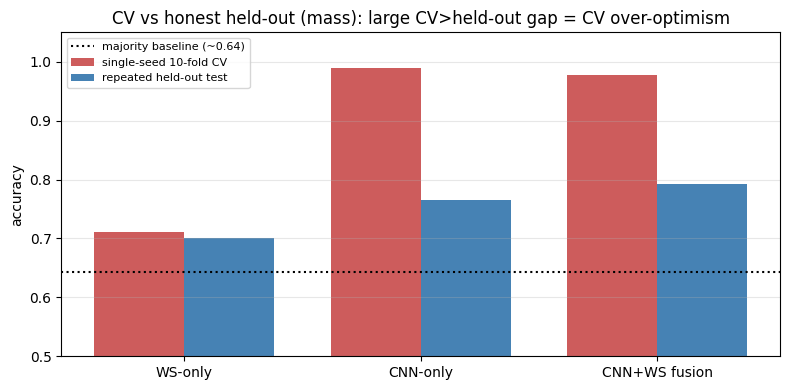

,method,cv,held_out,gap,biased
0,WS-only,0.711,0.701,0.010,False
1,CNN-only,0.989,0.766,0.223,True
2,CNN+WS fusion,0.978,0.792,0.186,True


In [15]:
# 3. CV-vs-held-out gap (CV optimism), per replication method
g = []
for m in ["WS-only (averaged)", "CNN-only (ResNet18->kNN)", "CNN+WS fusion (concat)"]:
    a = agg(m); cvv = cvmap[m]
    g.append(dict(method=m.split(" (")[0], cv=cvv[0], held_out=a["test_acc"], gap=cvv[0]-a["test_acc"], biased=cvv[2]))
gdf = pd.DataFrame(g)
fig, ax = plt.subplots(figsize=(8, 4)); x = np.arange(len(gdf)); w = 0.38
ax.bar(x-w/2, gdf["cv"], w, label="single-seed 10-fold CV", color="indianred")
ax.bar(x+w/2, gdf["held_out"], w, label="repeated held-out test", color="steelblue")
ax.axhline(0.643, ls=":", color="black", label="majority baseline (~0.64)")
ax.set_xticks(x); ax.set_xticklabels(gdf["method"]); ax.set_ylim(0.5, 1.05); ax.set_ylabel("accuracy")
ax.set_title("CV vs honest held-out (mass): large CV>held-out gap = CV over-optimism"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "cv_vs_heldout_gap.png", dpi=150, bbox_inches="tight"); plt.show()
display(gdf.round(3))

/tmp/ipykernel_91048/2194788447.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Majority", "WS-only", "CNN-only", "CNN+WS"], showmeans=True)


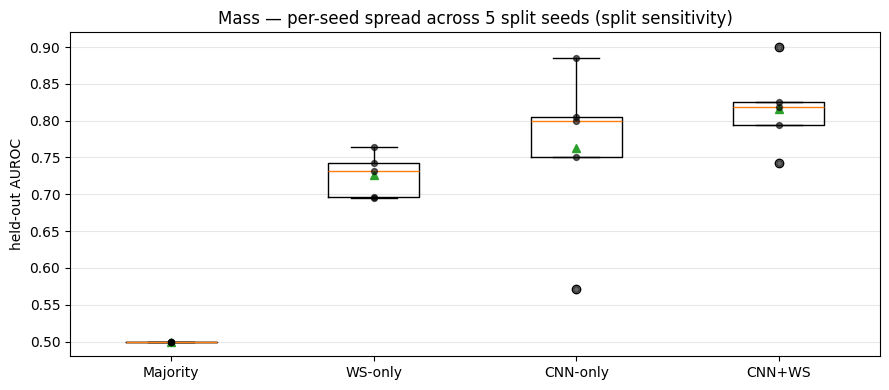

In [16]:
# 4. Per-seed spread (split sensitivity) — held-out AUROC across the 5 seeds
order = ["Majority baseline", "WS-only (averaged)", "CNN-only (ResNet18->kNN)", "CNN+WS fusion (concat)"]
data = [perseed[perseed["method"] == m]["auroc"].values for m in order]
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(data, labels=["Majority", "WS-only", "CNN-only", "CNN+WS"], showmeans=True)
for i, d in enumerate(data): ax.scatter(np.full(len(d), i+1), d, alpha=0.6, color="black", s=18, zorder=3)
ax.set_ylabel("held-out AUROC"); ax.set_title("Mass — per-seed spread across 5 split seeds (split sensitivity)"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "per_seed_spread_auroc.png", dpi=150, bbox_inches="tight"); plt.show()

**Reading the diagnostics (the dramatic case).** Unlike tissue (overfit gap ≈ 0.02), the mass CNN overfits
hard: training accuracy saturates near 100% within a few epochs while validation accuracy stalls around the
majority-class level and the validation loss *climbs* — the model becomes confidently wrong on unseen
patches. The overfit gap (train − test) is large, and the held-out confusion matrix / ROC show the resulting
instability on the tiny (n≈25) test set. This is exactly the regime the paper invokes to justify fusing the
training-free WS features with the CNN: the CV-vs-held-out panel shows the CNN/fusion single-seed CV (≈1.0)
sitting far above their honest held-out accuracy, i.e. the CV over-optimism behind the paper's headline.